# Time Series Dataset Analysis: Jena Climate Dataset

Notebook นี้จัดทำตามโจทย์การวิเคราะห์ Time Series Dataset จริง โดยใช้ **Jena Climate Dataset (2009–2016)**

### สิ่งที่จะทำใน Notebook
1. ระบุแหล่งที่มา จำนวนตัวอย่าง Sampling Interval ตัวแปร และ Target
2. แสดงกราฟ Time Series และวิเคราะห์ **Trend / Seasonality / Noise**
3. จัดการ **Missing Values / Noise / Scaling หรือ Normalization**
4. ทำ **Feature Engineering** เช่น Lag และ Rolling Statistics
5. แบ่งข้อมูลเป็น **Train / Validation / Test ตามลำดับเวลา**
6. อธิบายว่าทำไม Time Series จึงไม่ควรสุ่มข้อมูลแบบทั่วไป

> **Target ที่ใช้:** อุณหภูมิ `T (degC)`

## 1. ข้อมูล Dataset

**Dataset:** Jena Climate Dataset  
**แหล่งข้อมูล:** Max Planck Institute for Biogeochemistry (Jena, Germany)  
**ช่วงข้อมูล:** มกราคม 2009 – ธันวาคม 2016  
**Sampling Interval:** ทุก 10 นาที  
**จำนวนตัวอย่าง:** ประมาณ 420,000 แถว  
**ตัวแปร:** ข้อมูลสภาพอากาศหลายตัวแปร เช่น ความกดอากาศ อุณหภูมิ ความชื้น ไอน้ำ ลม และอื่น ๆ  
**Target:** `T (degC)` หรืออุณหภูมิหน่วยองศาเซลเซียส

แหล่งดาวน์โหลดที่ใช้ใน Notebook:
https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip

> หมายเหตุ: จำนวนแถวที่ได้จริงอาจแตกต่างเล็กน้อย หากมีการเปลี่ยนแปลงของไฟล์หรือขั้นตอนการทำความสะอาดข้อมูล

In [1]:
# ติดตั้ง/นำเข้า Library ที่จำเป็น
# หากเครื่องยังไม่มี ให้รัน:
# !pip install pandas numpy matplotlib scikit-learn requests

import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# 2. ดาวน์โหลด Dataset

DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
CSV_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")

URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading dataset...")
    response = requests.get(URL, timeout=60)
    response.raise_for_status()
    with open(ZIP_PATH, "wb") as f:
        f.write(response.content)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

print("CSV path:", CSV_PATH)
print("File exists:", os.path.exists(CSV_PATH))

CSV path: data\jena_climate_2009_2016.csv
File exists: True


In [3]:
# 3. โหลดข้อมูลและเตรียม DateTime

df = pd.read_csv(CSV_PATH)

# ชื่อคอลัมน์แรกคือ Date Time
df["Date Time"] = pd.to_datetime(df["Date Time"], dayfirst=True)

# เรียงตามเวลา
df = df.sort_values("Date Time").reset_index(drop=True)

# ตั้ง Date Time เป็น index
df = df.set_index("Date Time")

print("Shape:", df.shape)
display(df.head())
display(df.dtypes)

Shape: (420551, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object

## 4. Dataset Information

จากข้อมูลนี้ เราสามารถกำหนดได้ว่า:

- **Sampling Interval:** 10 นาที
- **Target:** `T (degC)`
- ตัวแปรอื่น ๆ สามารถใช้เป็น Exogenous Features ได้
- Index เป็นเวลา จึงสามารถนำมาใช้สร้าง Feature ที่เกี่ยวข้องกับเวลาได้

In [4]:
# ตรวจสอบข้อมูลพื้นฐาน

print("จำนวนตัวอย่างทั้งหมด:", len(df))
print("\nช่วงเวลา:")
print("เริ่ม:", df.index.min())
print("สิ้นสุด:", df.index.max())

print("\nจำนวนตัวแปรทั้งหมด:", len(df.columns))
print("\nตัวแปร:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nข้อมูลซ้ำ:", df.index.duplicated().sum())
print("\nMissing Values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

จำนวนตัวอย่างทั้งหมด: 420551

ช่วงเวลา:
เริ่ม: 2009-01-01 00:10:00
สิ้นสุด: 2017-01-01 00:00:00

จำนวนตัวแปรทั้งหมด: 14

ตัวแปร:
01. p (mbar)
02. T (degC)
03. Tpot (K)
04. Tdew (degC)
05. rh (%)
06. VPmax (mbar)
07. VPact (mbar)
08. VPdef (mbar)
09. sh (g/kg)
10. H2OC (mmol/mol)
11. rho (g/m**3)
12. wv (m/s)
13. max. wv (m/s)
14. wd (deg)

ข้อมูลซ้ำ: 327

Missing Values:


,missing_count
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0
H2OC (mmol/mol),0


In [5]:
# 5. ตรวจสอบ Sampling Interval

time_diff = df.index.to_series().diff().dropna()

print("Sampling interval ที่พบบ่อยที่สุด:")
print(time_diff.value_counts().head(10))

print("\nค่าเฉลี่ยของ interval:", time_diff.mean())

Sampling interval ที่พบบ่อยที่สุด:
Date Time
0 days 00:10:00    420218
0 days 00:00:00       327
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
3 days 02:20:00         1
Name: count, dtype: int64

ค่าเฉลี่ยของ interval: 0 days 00:10:00.309594


## 5.1 Sampling Interval

ข้อมูลถูกบันทึกทุกประมาณ **10 นาที** ซึ่งเป็น Sampling Interval ที่เหมาะกับการวิเคราะห์สภาพอากาศแบบละเอียด

สำหรับขั้นตอน Feature Engineering ภายหลัง เราจะใช้ข้อมูลราย 10 นาทีเดิม และสามารถสร้างค่าเฉลี่ยรายชั่วโมง/รายวันเพิ่มเติมได้ตามงานที่ต้องการ

count    420551.000000
mean          9.450147
std           8.423365
min         -23.010000
25%           3.360000
50%           9.420000
75%          15.470000
max          37.280000
Name: T (degC), dtype: float64

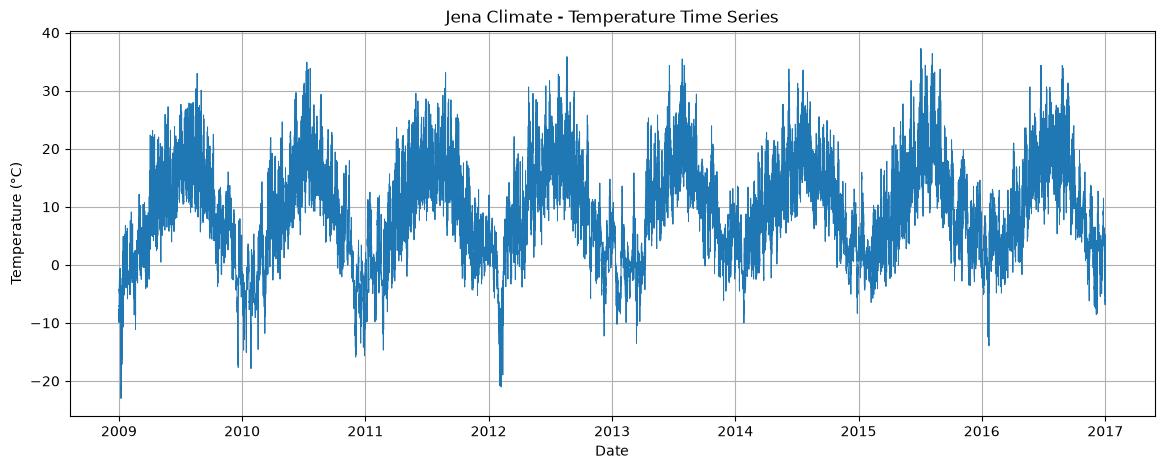

In [6]:
# 6. วิเคราะห์ Target

TARGET = "T (degC)"

display(df[TARGET].describe())

fig, ax = plt.subplots()
ax.plot(df.index, df[TARGET], linewidth=0.7)
ax.set_title("Jena Climate - Temperature Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
plt.show()

## 6.1 การวิเคราะห์ Trend / Seasonality / Noise

จากกราฟอุณหภูมิจะเห็นรูปแบบสำคัญ 3 อย่าง:

**Trend:** อุณหภูมิเปลี่ยนแปลงตามช่วงเวลาในระยะยาว โดยมีรูปแบบขึ้นลงตามปีและฤดูกาล

**Seasonality:** มีรูปแบบซ้ำตามเวลา โดยเฉพาะ
- Daily seasonality: กลางวัน/กลางคืน
- Yearly/Annual seasonality: ฤดูร้อน/ฤดูหนาว

**Noise:** มีการแกว่งระยะสั้นจากสภาพอากาศจริง ทำให้ค่าที่ติดกันไม่ได้เท่ากันตลอดเวลา

เพื่อแยก Pattern ระยะยาวออกจาก Noise จะใช้ Rolling Mean

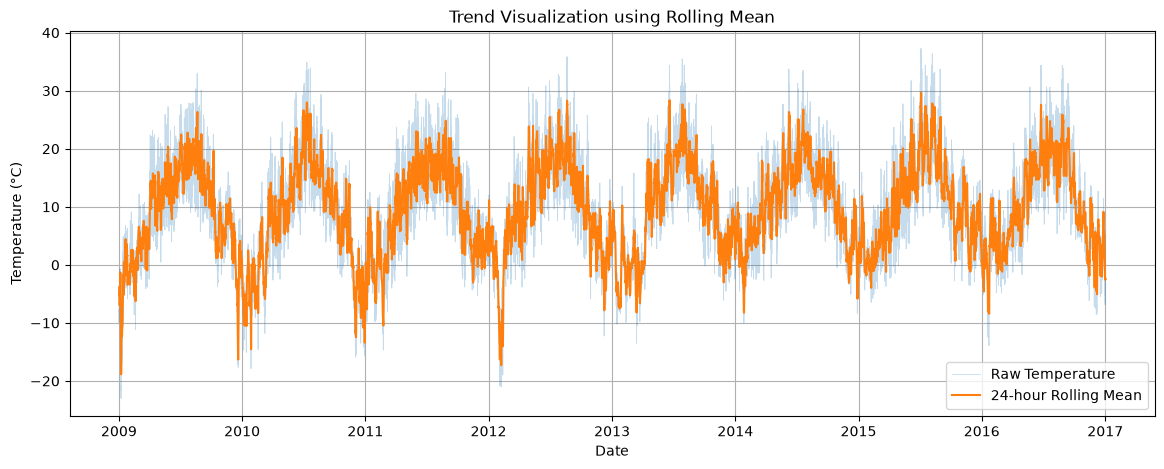

In [7]:
# 7. Rolling Mean เพื่อดู Trend ที่เรียบขึ้น

# 6 samples = 1 ชั่วโมง เนื่องจากข้อมูลทุก 10 นาที
df["temp_roll_1h"] = df[TARGET].rolling(window=6).mean()

# 144 samples = 1 วัน
df["temp_roll_1d"] = df[TARGET].rolling(window=144).mean()

fig, ax = plt.subplots()
ax.plot(df.index, df[TARGET], alpha=0.25, linewidth=0.6, label="Raw Temperature")
ax.plot(df.index, df["temp_roll_1d"], linewidth=1.5, label="24-hour Rolling Mean")
ax.set_title("Trend Visualization using Rolling Mean")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.show()

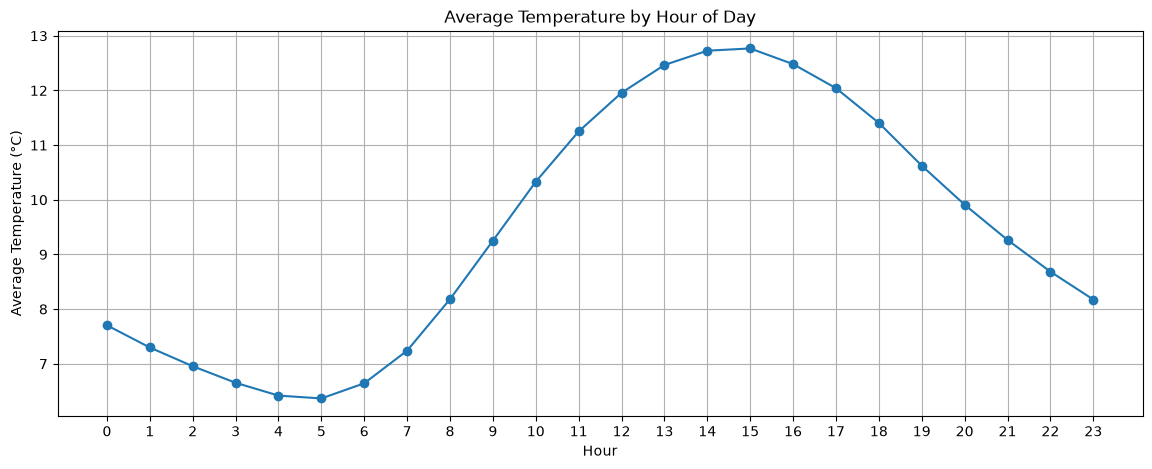

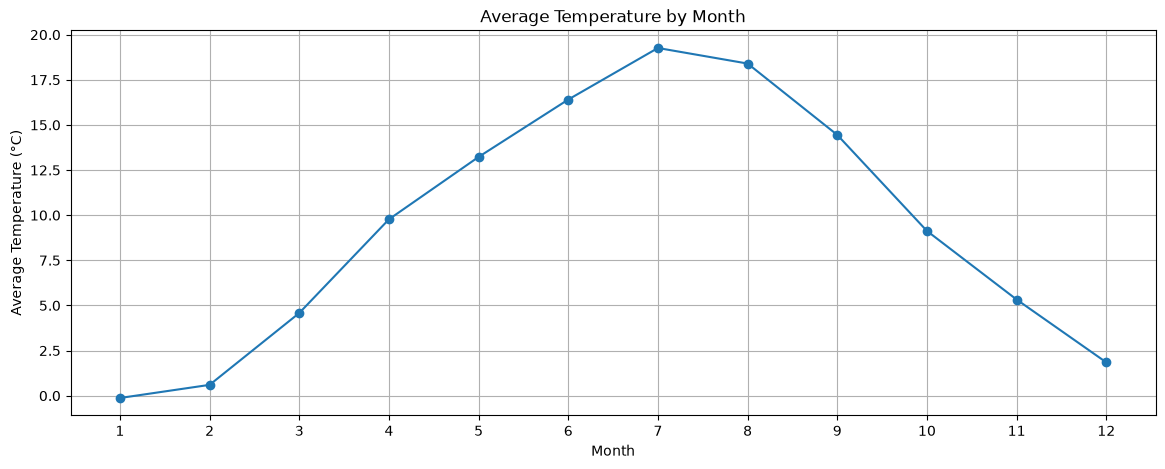

In [8]:
# 8. แสดง Seasonality แบบรายชั่วโมงและรายเดือน

analysis_df = df[[TARGET]].copy()
analysis_df["hour"] = analysis_df.index.hour
analysis_df["month"] = analysis_df.index.month

hour_mean = analysis_df.groupby("hour")[TARGET].mean()
month_mean = analysis_df.groupby("month")[TARGET].mean()

fig, ax = plt.subplots()
ax.plot(hour_mean.index, hour_mean.values, marker="o")
ax.set_title("Average Temperature by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Average Temperature (°C)")
ax.set_xticks(range(24))
plt.show()

fig, ax = plt.subplots()
ax.plot(month_mean.index, month_mean.values, marker="o")
ax.set_title("Average Temperature by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Temperature (°C)")
ax.set_xticks(range(1, 13))
plt.show()

## 9. Missing Values

แนวทางจัดการ Missing Values สำหรับ Time Series ควรคำนึงถึงลำดับเวลา

ในตัวอย่างนี้:
1. ตรวจสอบจำนวน Missing Values ก่อน
2. ใช้ **Time-based Interpolation** สำหรับตัวแปรเชิงตัวเลข
3. ตรวจสอบอีกครั้งหลังการเติมค่า

ไม่ควรเติมค่าแบบสุ่ม เพราะค่าที่หายไปควรสัมพันธ์กับข้อมูลก่อนหน้าและหลังหน้าในลำดับเวลา

In [9]:
# 9.1 Missing Values ก่อนจัดการ

missing_before = df.isna().sum().sort_values(ascending=False)
display(missing_before.to_frame("missing_before"))

# ทำสำเนาเฉพาะข้อมูลดิบก่อนสร้าง feature
data = df.drop(columns=["temp_roll_1h", "temp_roll_1d"], errors="ignore").copy()

# Interpolation ตามเวลา
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].interpolate(method="time")

# เผื่อกรณีหัว/ท้ายยังเป็น NaN
data[numeric_cols] = data[numeric_cols].bfill().ffill()

missing_after = data.isna().sum().sort_values(ascending=False)
display(missing_after.to_frame("missing_after"))

,missing_before
temp_roll_1d,143
temp_roll_1h,5
p (mbar),0
T (degC),0
rh (%),0
VPmax (mbar),0
Tpot (K),0
Tdew (degC),0
VPdef (mbar),0
VPact (mbar),0


,missing_after
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0
H2OC (mmol/mol),0


## 10. Noise Management

Noise เป็นส่วนหนึ่งของข้อมูลจริง จึงไม่ควรลบค่าที่ผิดปกติออกทั้งหมดโดยไม่ตรวจสอบ

แนวทางตัวอย่าง:
- ใช้ Rolling Median เพื่อดูค่าที่ผิดปกติระยะสั้น
- ใช้ IQR ตรวจสอบ Outlier ในเชิงสถิติ
- ไม่ลบ Outlier โดยอัตโนมัติ เพราะอุณหภูมิที่เปลี่ยนแปลงเร็วอาจเป็นเหตุการณ์จริง

ด้านล่างจะสร้างคอลัมน์สำหรับตรวจสอบ Outlier ด้วย IQR

In [10]:
# 10.1 ตรวจสอบ Outlier ของ Target ด้วย IQR

q1 = data[TARGET].quantile(0.25)
q3 = data[TARGET].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (data[TARGET] < lower) | (data[TARGET] > upper)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("จำนวนค่าที่เข้าข่าย IQR outlier:", outlier_mask.sum())
print("สัดส่วน:", f"{outlier_mask.mean()*100:.4f}%")

Q1: 3.36
Q3: 15.47
IQR: 12.110000000000001
Lower bound: -14.805000000000003
Upper bound: 33.635000000000005
จำนวนค่าที่เข้าข่าย IQR outlier: 1528
สัดส่วน: 0.3633%


In [11]:
# 10.2 แสดงตัวอย่างค่าที่เป็น Outlier

outlier_sample = data.loc[outlier_mask, [TARGET]].head(20)
display(outlier_sample)

,T (degC)
Date Time,
2009-01-06 04:50:00,-14.90
2009-01-06 05:00:00,-15.13
2009-01-06 05:10:00,-15.20
2009-01-06 05:20:00,-15.16
2009-01-06 05:30:00,-15.25
2009-01-06 05:40:00,-15.31
2009-01-06 05:50:00,-15.29
2009-01-06 06:00:00,-15.37
2009-01-06 06:10:00,-15.49


### ข้อสรุปเรื่อง Noise

ในงาน Time Series จริง ควรแยกคำว่า **Noise** ออกจาก **Outlier**:

- Noise = การแกว่งเล็ก ๆ ที่เกิดขึ้นตามธรรมชาติของการวัด
- Outlier = ค่าที่ผิดจากช่วงปกติมาก
- Outlier ไม่ได้แปลว่า "ข้อมูลผิด" เสมอไป

ดังนั้น Notebook นี้จะ **ไม่ลบ Outlier ทั้งหมด** แต่เก็บข้อมูลจริงไว้ และใช้ Rolling/Feature Engineering ช่วยให้โมเดลเรียนรู้รูปแบบได้ดีขึ้น

## 11. Feature Engineering

ตัวอย่าง Feature สำหรับ Time Series:

**Time Features**
- Hour
- Day of week
- Month

**Lag Features**
- ค่าอุณหภูมิเมื่อ 10 นาทีที่แล้ว
- ค่าเมื่อ 1 ชั่วโมงที่แล้ว
- ค่าเมื่อ 1 วันก่อน

**Rolling Features**
- ค่าเฉลี่ยย้อนหลัง 1 ชั่วโมง
- ค่าเฉลี่ยย้อนหลัง 6 ชั่วโมง
- ค่า Standard Deviation ย้อนหลัง 1 ชั่วโมง

Feature เหล่านี้ช่วยให้โมเดลรู้บริบทของเวลาและอดีต

In [12]:
# 12. สร้าง Feature Engineering

fe = data.copy()

# Time features
fe["hour"] = fe.index.hour
fe["day_of_week"] = fe.index.dayofweek
fe["month"] = fe.index.month
fe["day_of_year"] = fe.index.dayofyear

# Cyclical encoding
fe["hour_sin"] = np.sin(2 * np.pi * fe["hour"] / 24)
fe["hour_cos"] = np.cos(2 * np.pi * fe["hour"] / 24)

fe["month_sin"] = np.sin(2 * np.pi * fe["month"] / 12)
fe["month_cos"] = np.cos(2 * np.pi * fe["month"] / 12)

# Lag features
fe["lag_10min"] = fe[TARGET].shift(1)
fe["lag_1h"] = fe[TARGET].shift(6)
fe["lag_6h"] = fe[TARGET].shift(36)
fe["lag_1d"] = fe[TARGET].shift(144)

# Rolling features
fe["rolling_mean_1h"] = fe[TARGET].rolling(6).mean()
fe["rolling_std_1h"] = fe[TARGET].rolling(6).std()

fe["rolling_mean_6h"] = fe[TARGET].rolling(36).mean()
fe["rolling_mean_1d"] = fe[TARGET].rolling(144).mean()

# ลบแถวต้น ๆ ที่เกิด NaN จาก lag/rolling
fe = fe.dropna()

print("Shape หลัง Feature Engineering:", fe.shape)
display(fe.head())

Shape หลัง Feature Engineering: (420407, 30)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),hour,day_of_week,month,day_of_year,hour_sin,hour_cos,month_sin,month_cos,lag_10min,lag_1h,lag_6h,lag_1d,rolling_mean_1h,rolling_std_1h,rolling_mean_6h,rolling_mean_1d
Date Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2009-01-02 00:10:00,999.55,-4.60,268.60,-5.52,93.2,4.34,4.04,0.29,2.52,4.04,1294.58,0.85,1.38,151.2,0,4,1,2,0.0,1.0,0.5,0.866025,-4.54,-4.50,-5.16,-8.02,-4.481667,0.121559,-4.730556,-6.771111
2009-01-02 00:20:00,999.56,-4.67,268.53,-5.52,93.7,4.32,4.04,0.27,2.52,4.05,1294.91,0.83,1.50,148.8,0,4,1,2,0.0,1.0,0.5,0.866025,-4.60,-4.51,-5.12,-8.41,-4.508333,0.144418,-4.718056,-6.745139
2009-01-02 00:30:00,999.56,-4.66,268.53,-5.46,94.1,4.32,4.06,0.25,2.53,4.06,1294.89,0.53,1.38,154.3,0,4,1,2,0.0,1.0,0.5,0.866025,-4.67,-4.33,-5.04,-8.51,-4.563333,0.124365,-4.707500,-6.718403
2009-01-02 00:40:00,999.48,-4.55,268.65,-5.31,94.4,4.35,4.11,0.24,2.56,4.11,1294.22,0.41,1.25,159.3,0,4,1,2,0.0,1.0,0.5,0.866025,-4.66,-4.33,-5.01,-8.31,-4.600000,0.054772,-4.694722,-6.692292
2009-01-02 00:50:00,999.44,-4.43,268.77,-5.19,94.4,4.39,4.15,0.25,2.59,4.15,1293.56,0.63,1.13,192.1,0,4,1,2,0.0,1.0,0.5,0.866025,-4.55,-4.58,-5.12,-8.27,-4.575000,0.089163,-4.675556,-6.665625


## 13. Scaling / Normalization

สำหรับ Machine Learning เราควร Scale Feature เพื่อให้ค่าของตัวแปรอยู่ในช่วงที่เหมาะสม

ใน Notebook นี้เลือกใช้:

**StandardScaler**
\[
z = \frac{x-\mu}{\sigma}
\]

ข้อสำคัญมากสำหรับ Time Series คือ:

> ต้อง `fit()` scaler ด้วยข้อมูล **Train เท่านั้น**

ห้าม fit จาก Validation หรือ Test เพราะจะทำให้เกิด **Data Leakage**

In [13]:
# 14. แบ่ง Train / Validation / Test ตามลำดับเวลา

n = len(fe)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = fe.iloc[:train_end].copy()
val = fe.iloc[train_end:val_end].copy()
test = fe.iloc[val_end:].copy()

print("Train:", train.shape, train.index.min(), "->", train.index.max())
print("Validation:", val.shape, val.index.min(), "->", val.index.max())
print("Test:", test.shape, test.index.min(), "->", test.index.max())

Train: (294284, 30) 2009-01-02 00:10:00 -> 2014-08-05 09:30:00
Validation: (63061, 30) 2014-08-05 09:40:00 -> 2015-10-17 23:30:00
Test: (63062, 30) 2015-10-17 23:40:00 -> 2017-01-01 00:00:00


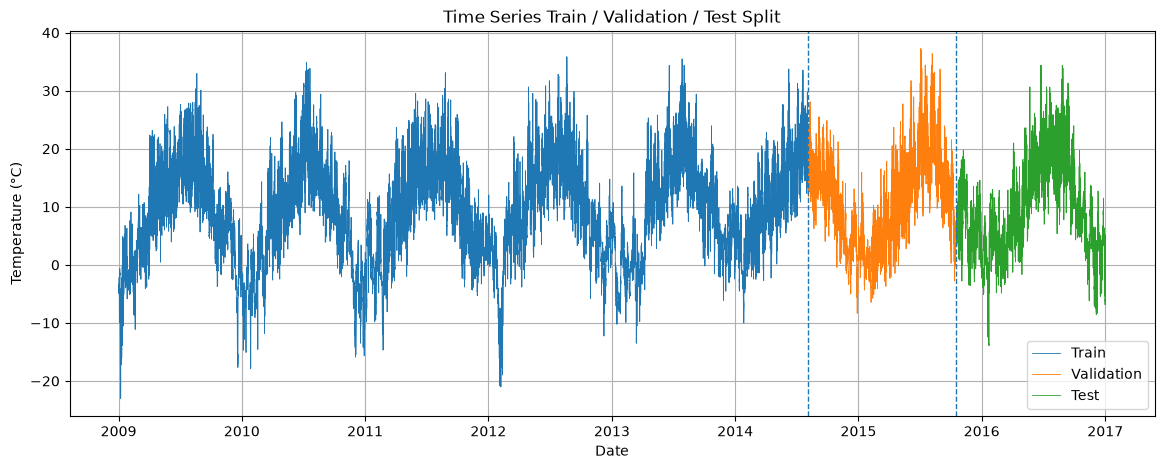

In [14]:
# 15. Visualize Time-based Split

fig, ax = plt.subplots()

ax.plot(train.index, train[TARGET], label="Train", linewidth=0.6)
ax.plot(val.index, val[TARGET], label="Validation", linewidth=0.6)
ax.plot(test.index, test[TARGET], label="Test", linewidth=0.6)

ax.axvline(val.index.min(), linestyle="--", linewidth=1)
ax.axvline(test.index.min(), linestyle="--", linewidth=1)

ax.set_title("Time Series Train / Validation / Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.show()

## 16. Scaling โดย Fit จาก Train เท่านั้น

ขั้นตอน:
1. เลือก Feature ที่ใช้
2. `fit_transform()` เฉพาะ Train
3. `transform()` กับ Validation
4. `transform()` กับ Test

วิธีนี้ช่วยป้องกัน Data Leakage

In [15]:
# 16.1 เลือก Feature และ Target

feature_cols = [
    "p (mbar)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "hour",
    "day_of_week",
    "month",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "lag_10min",
    "lag_1h",
    "lag_6h",
    "lag_1d",
    "rolling_mean_1h",
    "rolling_std_1h",
    "rolling_mean_6h",
    "rolling_mean_1d"
]

X_train = train[feature_cols]
y_train = train[TARGET]

X_val = val[feature_cols]
y_val = val[TARGET]

X_test = test[feature_cols]
y_test = test[TARGET]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (294284, 27)
X_val_scaled: (63061, 27)
X_test_scaled: (63062, 27)


In [16]:
# 17. ตรวจสอบว่า Scaling ทำงานถูกต้อง

scaled_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)

check = pd.DataFrame({
    "mean_after_scaling": scaled_train_df.mean(),
    "std_after_scaling": scaled_train_df.std()
})

display(check.head(10))

,mean_after_scaling,std_after_scaling
p (mbar),9.960791e-15,1.000002
Tpot (K),3.146164e-15,1.000002
Tdew (degC),-6.181068e-18,1.000002
rh (%),-2.812386e-16,1.000002
VPmax (mbar),8.035388e-17,1.000002
VPact (mbar),-3.523209e-16,1.000002
VPdef (mbar),-3.399587e-17,1.000002
sh (g/kg),-6.181068e-17,1.000002
H2OC (mmol/mol),4.141316e-16,1.000002
rho (g/m**3),-3.498484e-15,1.000002


## 18. ทำไมไม่ควรสุ่มข้อมูลแบบทั่วไป?

สำหรับข้อมูล Time Series ข้อมูลแต่ละแถวมี **ลำดับเวลาและความสัมพันธ์กับอดีต**

ตัวอย่าง:
- เราต้องการทำนายอุณหภูมิวันที่ 10 มกราคม
- ข้อมูลของวันที่ 11 มกราคมไม่ควรถูกนำมาใช้เป็นข้อมูล Train เพื่อทำนายวันที่ 10 มกราคม

ถ้าใช้ `train_test_split(..., shuffle=True)` จะเกิดปัญหา:

### 1. Data Leakage
ข้อมูลอนาคตอาจหลุดเข้าไปใน Train

### 2. ผิดลักษณะการใช้งานจริง
ระบบจริงจะรู้เฉพาะอดีต ไม่รู้อนาคต

### 3. ประเมินผลดีเกินจริง
โมเดลอาจได้คะแนนสูง แต่เมื่อนำไปใช้จริงกลับทำงานแย่

ดังนั้น Time Series ควรแบ่งข้อมูลเป็น:

**อดีต → Train → Validation → Test → อนาคต**

โดยรักษาลำดับเวลาเอาไว้

In [17]:
# 19. สรุปข้อมูลสำหรับรายงาน

summary = pd.DataFrame({
    "รายการ": [
        "Dataset",
        "แหล่งข้อมูล",
        "จำนวนตัวอย่างก่อน Feature Engineering",
        "จำนวนตัวอย่างหลัง Feature Engineering",
        "Sampling Interval",
        "Target",
        "Train",
        "Validation",
        "Test",
        "Scaling",
        "Missing Value Method",
        "Noise / Outlier Method"
    ],
    "รายละเอียด": [
        "Jena Climate Dataset",
        "Max Planck Institute / TensorFlow Dataset mirror",
        len(data),
        len(fe),
        "10 minutes",
        TARGET,
        f"{len(train)} ({len(train)/len(fe):.0%})",
        f"{len(val)} ({len(val)/len(fe):.0%})",
        f"{len(test)} ({len(test)/len(fe):.0%})",
        "StandardScaler (fit จาก Train เท่านั้น)",
        "Time interpolation + backward/forward fill",
        "ตรวจสอบ IQR และไม่ลบ Outlier อัตโนมัติ"
    ]
})

display(summary)

,รายการ,รายละเอียด
0,Dataset,Jena Climate Dataset
1,แหล่งข้อมูล,Max Planck Institute / TensorFlow Dataset mirror
2,จำนวนตัวอย่างก่อน Feature Engineering,420551
3,จำนวนตัวอย่างหลัง Feature Engineering,420407
4,Sampling Interval,10 minutes
5,Target,T (degC)
6,Train,294284 (70%)
7,Validation,63061 (15%)
8,Test,63062 (15%)
9,Scaling,StandardScaler (fit จาก Train เท่านั้น)


# 20. สรุปสำหรับเขียนรายงาน

### Dataset
เลือกใช้ **Jena Climate Dataset** ซึ่งเป็นข้อมูลสภาพอากาศจริงจากสถานีตรวจวัดในเมือง Jena ประเทศเยอรมนี บันทึกข้อมูลทุก 10 นาที

### Trend / Seasonality / Noise
ข้อมูลอุณหภูมิมีรูปแบบการเปลี่ยนแปลงระยะยาวและรูปแบบตามฤดูกาล รวมถึงความผันผวนระยะสั้นจากสภาพอากาศจริง

### Missing Values
ตรวจสอบ Missing Values และใช้ Time-based Interpolation โดยอาศัยข้อมูลตามลำดับเวลา

### Noise
ไม่ลบค่าผิดปกติทั้งหมด เพราะค่าที่ดูผิดปกติอาจเป็นเหตุการณ์จริง จึงใช้ IQR เพื่อตรวจสอบ และใช้ Rolling Statistics เพื่อช่วยลดผลกระทบของความผันผวนระยะสั้นในการสร้าง Feature

### Scaling
ใช้ StandardScaler และ `fit()` เฉพาะ Train เพื่อป้องกัน Data Leakage

### Feature Engineering
สร้าง Time Features, Cyclical Features, Lag Features และ Rolling Features เพื่อให้โมเดลสามารถใช้ข้อมูลในอดีตและรูปแบบตามเวลาได้

### Train / Validation / Test
แบ่งข้อมูลตามลำดับเวลา **70% / 15% / 15%** โดยไม่ Shuffle เพื่อจำลองการใช้งานจริง ซึ่งโมเดลจะใช้ข้อมูลอดีตเพื่อทำนายอนาคต

## ที่มาของ Dataset

**Jena Climate Dataset (2009–2016)**  
Dataset mirror: TensorFlow / Keras  
https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip

ใช้สำหรับการศึกษาและสาธิตงาน Time Series / Weather Forecasting ใน Notebook นี้